# Veterinary Pharmacovigilance Analysis

## Objective
The objective of this project is to analyze adverse drug events in dogs and cats using veterinary pharmacovigilance data.

This analysis focuses on:
- Identifying the most frequently reported drugs
- Understanding which species are most affected
- Detecting the most common adverse reactions

## Background
Pharmacovigilance plays a key role in monitoring drug safety. By analyzing adverse event reports, we can identify patterns that help improve treatment decisions and animal health outcomes.

## Tools Used
- Python
- Pandas
- Data Visualization (Matplotlib, Seaborn)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
import requests
import pandas as pd

url = "https://api.fda.gov/animalandveterinary/event.json?limit=1000"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data["results"])

print("Raw outcome sample:", data["results"][0]["outcome"])
print("Raw reaction sample:", data["results"][0]["reaction"])

df.head()

Raw outcome sample: [{'medical_status': 'Outcome Unknown', 'number_of_animals_affected': '1'}]
Raw reaction sample: [{'veddra_version': '11', 'veddra_term_code': '1018', 'veddra_term_name': "Lethargy (see also Central nervous system depression in 'Neurological')", 'number_of_animals_affected': '1', 'accuracy': 'Actual'}, {'veddra_version': '11', 'veddra_term_code': '686', 'veddra_term_name': 'Twitching', 'number_of_animals_affected': '1', 'accuracy': 'Actual'}]


,treated_for_ae,reaction,unique_aer_id_number,original_receive_date,number_of_animals_affected,primary_reporter,number_of_animals_treated,drug,onset_date,foreign_or_domestic,...,animal.weight.unit,animal.weight.qualifier,animal.breed.is_crossbred,animal.breed.breed_component,secondary_reporter,duration.value,duration.unit,time_between_exposure_and_onset,animal.age.max,animal.weight.max
0,true,"[{'veddra_version': '11', 'veddra_term_code': ...",USA-USFDACVM-2019-US-035461,20190723,1,Animal Owner,1,"[{'first_exposure_date': '20190720', 'last_exp...",20190721,Domestic,...,Kilogram,Measured,false,Spaniel - Cocker English,NaN,NaN,NaN,NaN,NaN,NaN
1,false,"[{'veddra_version': '6', 'veddra_term_code': '...",USA-USFDACVM-2018-US-025515,20180525,1,Veterinarian,1,"[{'first_exposure_date': '20170807', 'last_exp...",20180523,Domestic,...,Kilogram,Measured,true,"[Mastiff, Bulldog]",Animal Owner,NaN,NaN,NaN,NaN,NaN
2,true,"[{'veddra_version': '11', 'veddra_term_code': ...",USA-USFDACVM-2020-US-036207,20200717,1,Animal Owner,1,"[{'first_exposure_date': '20190326', 'frequenc...",20200715,Domestic,...,Kilogram,Measured,false,Doberman Pinscher,Veterinarian,NaN,NaN,NaN,NaN,NaN
3,false,"[{'veddra_version': '11', 'veddra_term_code': ...",USA-USFDACVM-2018-US-029375,20180516,1,Animal Owner,1,"[{'first_exposure_date': '20180101', 'last_exp...",20180515,Domestic,...,NaN,Unknown,false,Dog (unknown),NaN,NaN,NaN,NaN,NaN,NaN
4,false,"[{'veddra_version': '11', 'veddra_term_code': ...",USA-USFDACVM-2019-US-043170,20190820,1,Animal Owner,1,"[{'first_exposure_date': '20190721', 'last_exp...",20190721,Domestic,...,Kilogram,Measured,false,Poodle - Toy,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print("Columns:", df.columns.tolist())

Columns: ['treated_for_ae', 'reaction', 'unique_aer_id_number', 'original_receive_date', 'number_of_animals_affected', 'primary_reporter', 'number_of_animals_treated', 'drug', 'onset_date', 'foreign_or_domestic', 'report_id', 'type_of_information', 'serious_ae', 'outcome', 'receiver.organization', 'receiver.street_address', 'receiver.city', 'receiver.state', 'receiver.postal_code', 'receiver.country', 'health_assessment_prior_to_exposure.condition', 'health_assessment_prior_to_exposure.assessed_by', 'animal_species', 'animal.gender', 'animal.reproductive_status', 'animal.female_animal_physiological_status', 'animal.age.min', 'animal.age.unit', 'animal.age.qualifier', 'animal.weight.min', 'animal.weight.unit', 'animal.weight.qualifier', 'animal.breed.is_crossbred', 'animal.breed.breed_component', 'secondary_reporter', 'duration.value', 'duration.unit', 'time_between_exposure_and_onset', 'animal.age.max', 'animal.weight.max', 'outcome_severity', 'receivedate', 'breed']


In [162]:
df.isnull().sum()

treated_for_ae                                     449
reaction                                             0
unique_aer_id_number                                 0
original_receive_date                                0
number_of_animals_affected                          95
primary_reporter                                     3
number_of_animals_treated                           95
drug                                                 0
onset_date                                          91
foreign_or_domestic                                  0
report_id                                            0
type_of_information                                  0
serious_ae                                         379
outcome                                            341
receiver.organization                                0
receiver.street_address                              0
receiver.city                                        0
receiver.state                                       0
receiver.p

In [4]:
df.rename(columns={
    "animal.species": "animal_species",
    "reaction.reactionmeddrapt": "reaction"
}, inplace=True)

print("Columns after rename:", df.columns.tolist())

Columns after rename: ['treated_for_ae', 'reaction', 'unique_aer_id_number', 'original_receive_date', 'number_of_animals_affected', 'primary_reporter', 'number_of_animals_treated', 'drug', 'onset_date', 'foreign_or_domestic', 'report_id', 'type_of_information', 'serious_ae', 'outcome', 'receiver.organization', 'receiver.street_address', 'receiver.city', 'receiver.state', 'receiver.postal_code', 'receiver.country', 'health_assessment_prior_to_exposure.condition', 'health_assessment_prior_to_exposure.assessed_by', 'animal_species', 'animal.gender', 'animal.reproductive_status', 'animal.female_animal_physiological_status', 'animal.age.min', 'animal.age.unit', 'animal.age.qualifier', 'animal.weight.min', 'animal.weight.unit', 'animal.weight.qualifier', 'animal.breed.is_crossbred', 'animal.breed.breed_component', 'secondary_reporter', 'duration.value', 'duration.unit', 'time_between_exposure_and_onset', 'animal.age.max', 'animal.weight.max']


In [5]:
df["reaction"] = df["reaction"].apply(lambda x: x[0]["veddra_term_name"] if isinstance(x, list) and x and isinstance(x[0], dict) and "veddra_term_name" in x[0] else "")

In [22]:
# Shorten verbose reaction labels — remove "(see also ...)" explanatory text
df["reaction"] = df["reaction"].str.replace(r"\s*\(see also[^)]*\)", "", regex=True).str.strip()

# Convert fully all-caps labels to title case (e.g. "INEFFECTIVE, HEARTWORM LARVAE")
df["reaction"] = df["reaction"].apply(lambda x: x.title() if isinstance(x, str) and x == x.upper() and x else x)


In [165]:
print("Sample reactions:")
print(df["reaction"].head())

Sample reactions:
0    Lethargy (see also Central nervous system depr...
1                        INEFFECTIVE, HEARTWORM ADULTS
2          Lack of efficacy (endoparasite) - heartworm
3                                            Diarrhoea
4    Lethargy (see also Central nervous system depr...
Name: reaction, dtype: object


In [6]:
def extract_drug_name(drug_entry):
    if isinstance(drug_entry, list) and drug_entry:
        return extract_drug_name(drug_entry[0])
    if isinstance(drug_entry, dict):
        # brand_name is often "MSK" (masked by FDA) — skip it
        # use active_ingredients first
        ingredients = drug_entry.get("active_ingredients") or drug_entry.get("active_ingredient")
        if isinstance(ingredients, list) and ingredients and isinstance(ingredients[0], dict):
            name = ingredients[0].get("name", "")
            if name and name.upper() != "MSK":
                return name
        brand = drug_entry.get("brand_name", "")
        if brand and brand.upper() != "MSK":
            return brand
        return "unknown"
    return "unknown"

# extraer nombre del medicamento
df["drug"] = df["drug"].apply(extract_drug_name).astype(str).str.lower()

In [167]:
print("Before dropna shape:", df.shape)
print("Animal species unique:", df["animal_species"].unique()[:10])

Before dropna shape: (1000, 40)
Animal species unique: ['Dog' nan 'Cat' 'Horse' 'Goat' 'Human' 'Pig' 'Cattle' 'Sheep' 'Rabbit']


In [168]:
print("Animal species before lower:", df["animal_species"].value_counts(dropna=False).head())

Animal species before lower: animal_species
Dog       733
Cat       109
NaN        95
Cattle     32
Horse      11
Name: count, dtype: int64


In [8]:
df["animal_species"] = df["animal_species"].astype(str).str.lower()
df = df[df["animal_species"].isin(["dog", "cat"])]

In [15]:

# Extract outcome severity from nested outcome list
def extract_outcome(outcome_entry):
    if isinstance(outcome_entry, list) and outcome_entry:
        first = outcome_entry[0]
        if isinstance(first, dict):
            return first.get("medical_status", "unknown").lower()
    if isinstance(outcome_entry, dict):
        return outcome_entry.get("medical_status", "unknown").lower()
    return "unknown"

df["outcome_severity"] = df["outcome"].apply(extract_outcome)

# Parse receive date
df["receivedate"] = pd.to_datetime(df["original_receive_date"], format="%Y%m%d", errors="coerce")

print("Outcome severity counts:")
print(df["outcome_severity"].value_counts())
print("\nDate range:", df["receivedate"].min(), "to", df["receivedate"].max())


Outcome severity counts:
outcome_severity
unknown                   221
recovered/normal          206
outcome unknown           185
ongoing                   173
died                       28
recovered with sequela     17
euthanized                 12
Name: count, dtype: int64

Date range: 1987-06-22 00:00:00 to 2025-12-23 00:00:00


In [170]:
print("Animal species values:", df["animal_species"].unique())

Animal species values: ['Dog' nan 'Cat' 'Horse' 'Goat' 'Human' 'Pig' 'Cattle' 'Sheep' 'Rabbit'
 'Other' 'Fish' 'Rat']


In [171]:
print("Shape:", df.shape)
print("Drug counts:", df["drug"].value_counts().head())

Shape: (1000, 40)
Drug counts: drug
msk    1000
Name: count, dtype: int64


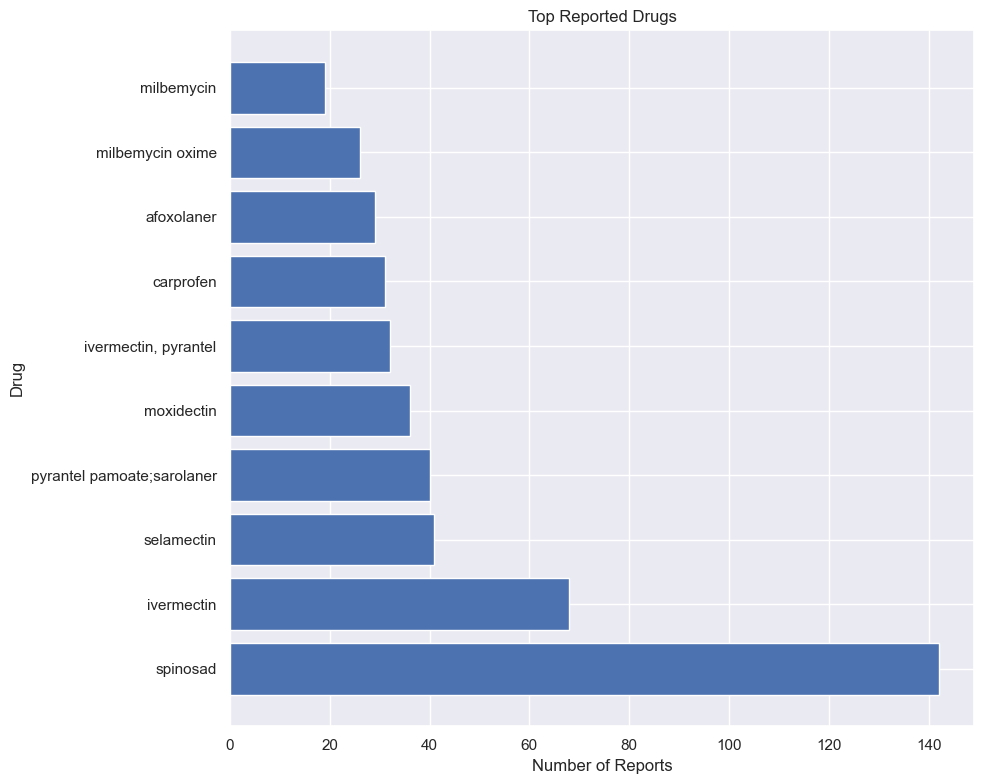

In [9]:
top_drugs = df["drug"].astype(str).value_counts().head(10)

plt.figure(figsize=(10,8))
plt.barh(range(len(top_drugs)), top_drugs.values)
plt.yticks(range(len(top_drugs)), top_drugs.index)
plt.title("Top Reported Drugs")
plt.xlabel("Number of Reports")
plt.ylabel("Drug")
plt.tight_layout()
plt.show()

In [173]:
print("Top drugs:")
print(top_drugs)

Top drugs:
drug
msk    1000
Name: count, dtype: int64


In [174]:
print("Drug column sample:")
print(df["drug"].head())

Drug column sample:
0    msk
1    msk
2    msk
3    msk
4    msk
Name: drug, dtype: object


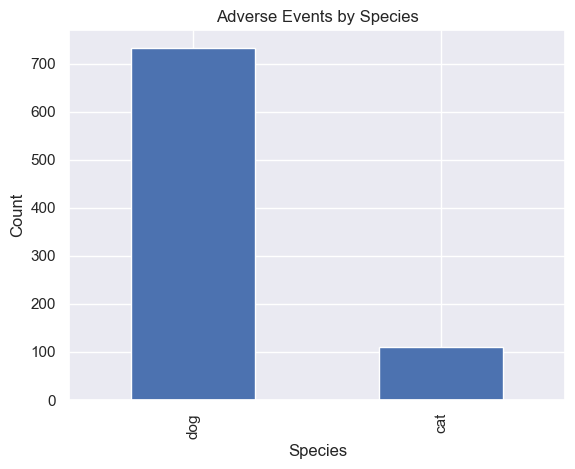

In [10]:
species_counts = df["animal_species"].value_counts()

plt.figure()
species_counts.plot(kind="bar")
plt.title("Adverse Events by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

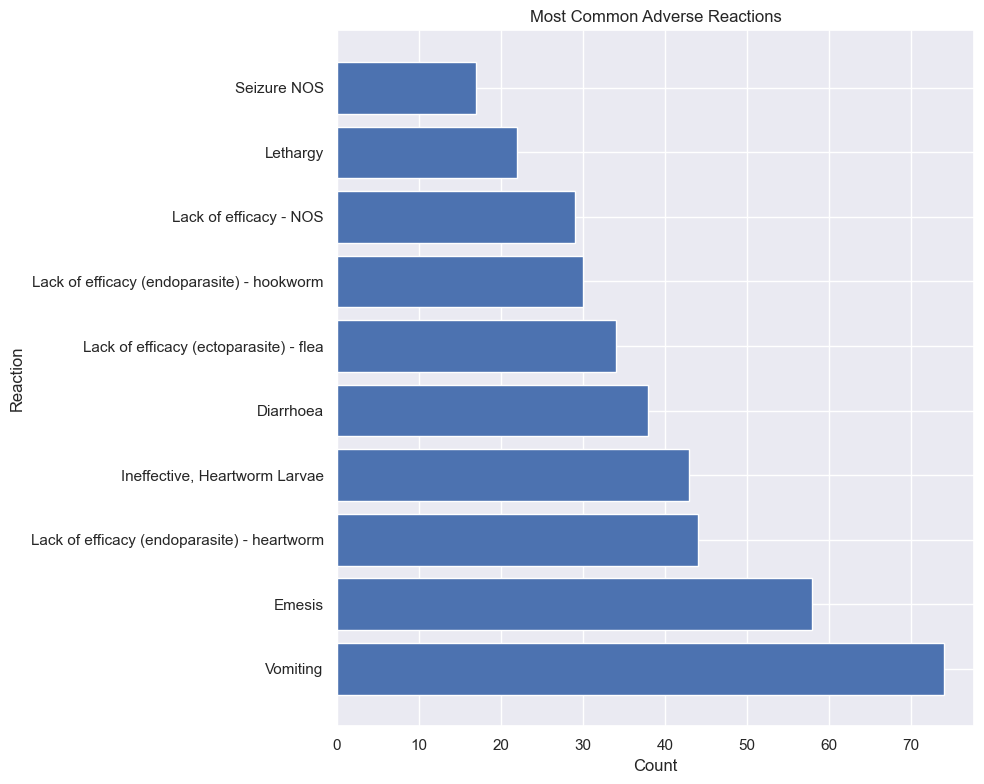

In [23]:
top_reactions = df["reaction"].value_counts().head(10)

plt.figure(figsize=(10,8))
plt.barh(range(len(top_reactions)), top_reactions.values)
plt.yticks(range(len(top_reactions)), top_reactions.index)
plt.title("Most Common Adverse Reactions")
plt.xlabel("Count")
plt.ylabel("Reaction")
plt.tight_layout()
plt.show()

In [24]:
top_reactions_list = df["reaction"].value_counts().head(10).index
df_top = df[df["reaction"].isin(top_reactions_list)]
reaction_species = pd.crosstab(df_top["reaction"], df_top["animal_species"])
# keep only dog and cat columns if others leaked through
for col in reaction_species.columns:
    if col not in ["dog", "cat"]:
        reaction_species = reaction_species.drop(columns=col)

reaction_species.head(10)

animal_species,cat,dog
reaction,,
Diarrhoea,4,34
Emesis,2,56
"Ineffective, Heartworm Larvae",0,43
Lack of efficacy (ectoparasite) - flea,7,27
Lack of efficacy (endoparasite) - heartworm,0,44
Lack of efficacy (endoparasite) - hookworm,0,30
Lack of efficacy - NOS,6,23
Lethargy,7,15
Seizure NOS,1,16


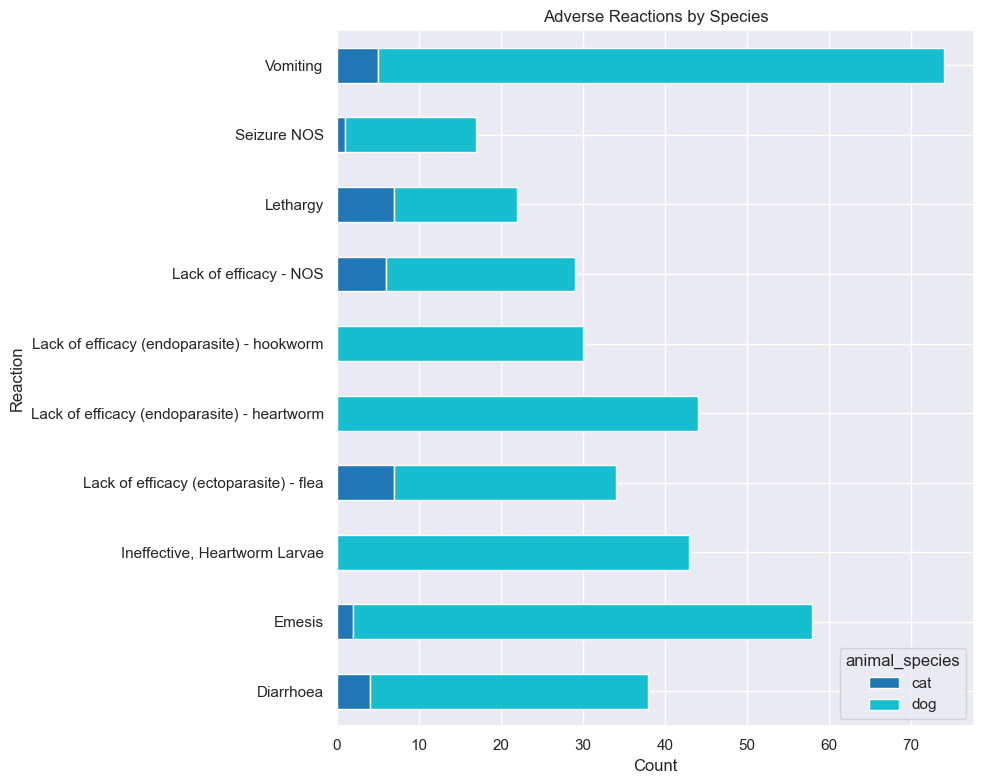

In [25]:

reaction_species_plot = reaction_species.copy()
ax = reaction_species_plot.plot(kind="barh", stacked=True, figsize=(10, 8), colormap="tab10")
plt.title("Adverse Reactions by Species")
plt.xlabel("Count")
plt.ylabel("Reaction")
plt.legend(title="animal_species")
plt.tight_layout()
plt.show()


## Analyzing Outcomes Severity
The severity of outcomes provides insights into the impact of adverse events on animal health.

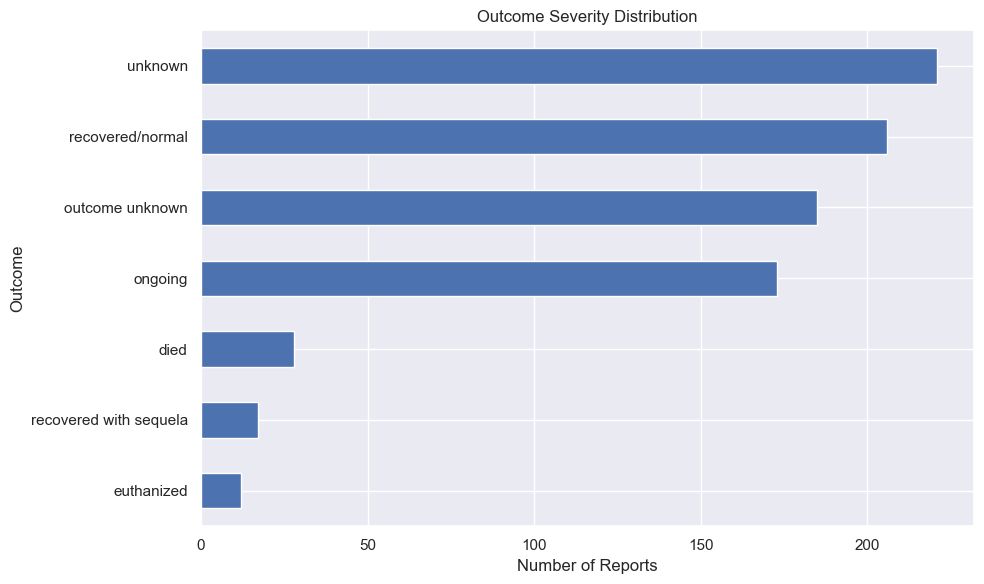

In [16]:

top_severities = df["outcome_severity"].value_counts()

plt.figure(figsize=(10, 6))
top_severities.sort_values().plot(kind="barh")
plt.title("Outcome Severity Distribution")
plt.xlabel("Number of Reports")
plt.ylabel("Outcome")
plt.tight_layout()
plt.show()


In [ ]:
print("Outcome severities:")
print(df["outcome_severity"].value_counts())

Outcome severities:
outcome_severity
nan                                                                                                                                                                                                                     341
[{'medical_status': 'recovered/normal', 'number_of_animals_affected': '1'}]                                                                                                                                             208
[{'medical_status': 'outcome unknown', 'number_of_animals_affected': '1'}]                                                                                                                                              177
[{'medical_status': 'ongoing', 'number_of_animals_affected': '1'}]                                                                                                                                                      171
[{'medical_status': 'died', 'number_of_animals_affected': '1'}]                    

## Exploring Trends Over Time

Analyzing trends in adverse events over time helps identify if certain issues are increasing or decreasing.

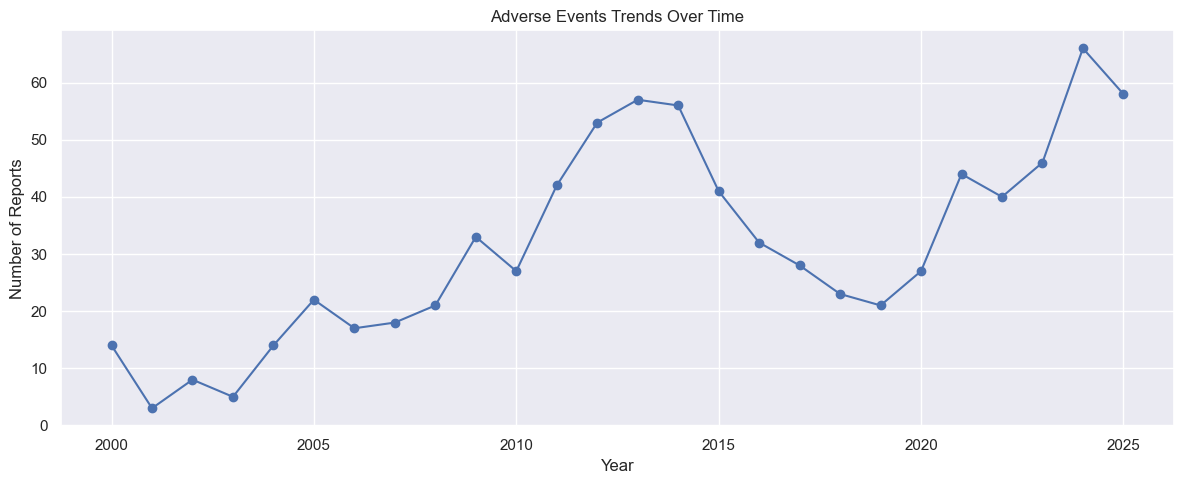

In [17]:

df_dated = df.dropna(subset=["receivedate"])
df_dated = df_dated[df_dated["receivedate"].dt.year >= 2000]
trends = df_dated.groupby(df_dated["receivedate"].dt.year).size()

plt.figure(figsize=(12, 5))
trends.plot(kind="line", marker="o")
plt.title("Adverse Events Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.show()


## Analysis by Breed

Examining which breeds are most frequently reported in adverse events helps identify potential genetic predispositions to drug toxicity — most notably the MDR1/ABCB1 mutation present in herding breeds, which causes severe sensitivity to Ivermectin.


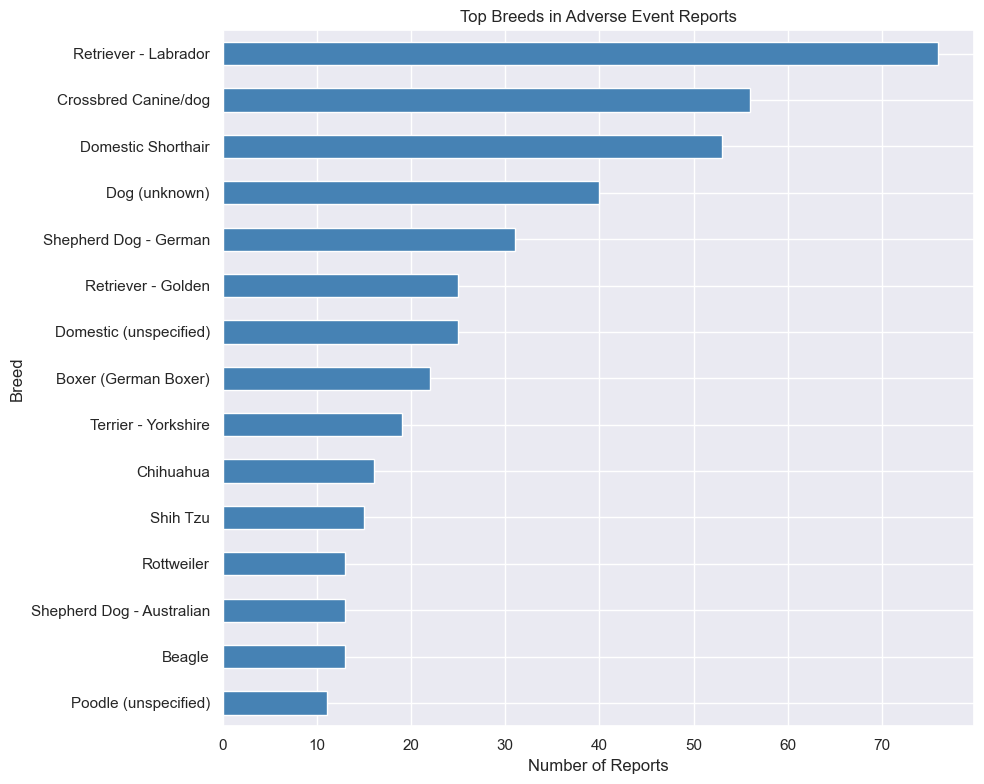

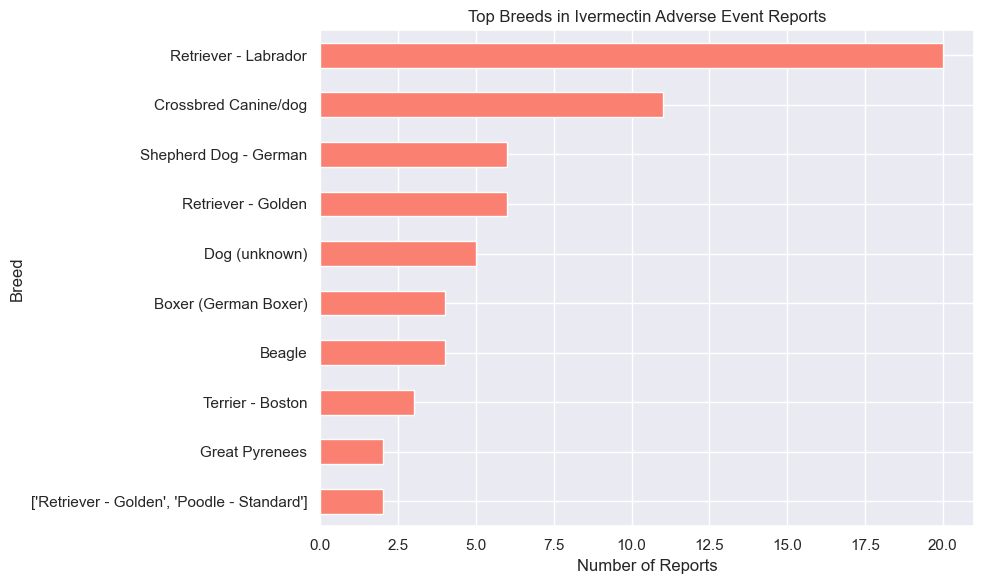

In [28]:

# Extract breed from the correct column
breed_col = "animal.breed.breed_component"

df["breed"] = df[breed_col].astype(str).str.strip()
df["breed"] = df["breed"].replace({"nan": "Unknown", "None": "Unknown", "": "Unknown"})

# Top breeds overall
top_breeds = df[df["breed"] != "Unknown"]["breed"].value_counts().head(15)

plt.figure(figsize=(10, 8))
top_breeds.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top Breeds in Adverse Event Reports")
plt.xlabel("Number of Reports")
plt.ylabel("Breed")
plt.tight_layout()
plt.show()

# Ivermectin adverse events by breed
df_iver = df[(df["drug"].str.contains("ivermectin", na=False)) & (df["breed"] != "Unknown")]
iver_breeds = df_iver["breed"].value_counts().head(10)

if len(iver_breeds) > 0:
    plt.figure(figsize=(10, 6))
    iver_breeds.sort_values().plot(kind="barh", color="salmon")
    plt.title("Top Breeds in Ivermectin Adverse Event Reports")
    plt.xlabel("Number of Reports")
    plt.ylabel("Breed")
    plt.tight_layout()
    plt.show()


## Safety Signal Detection — Proportional Reporting Ratio (PRR)

The **Proportional Reporting Ratio (PRR)** is the standard statistical method used in pharmacovigilance by the FDA and EMA to detect drug safety signals. A PRR ≥ 2 with at least 3 reports for a drug-reaction pair indicates a potential signal worth clinical investigation.

$$PRR = \frac{a/(a+b)}{c/(c+d)}$$

Where **a** = reports with drug + reaction, **b** = reports with drug but no reaction, **c** = reports without drug but with reaction, **d** = reports with neither.


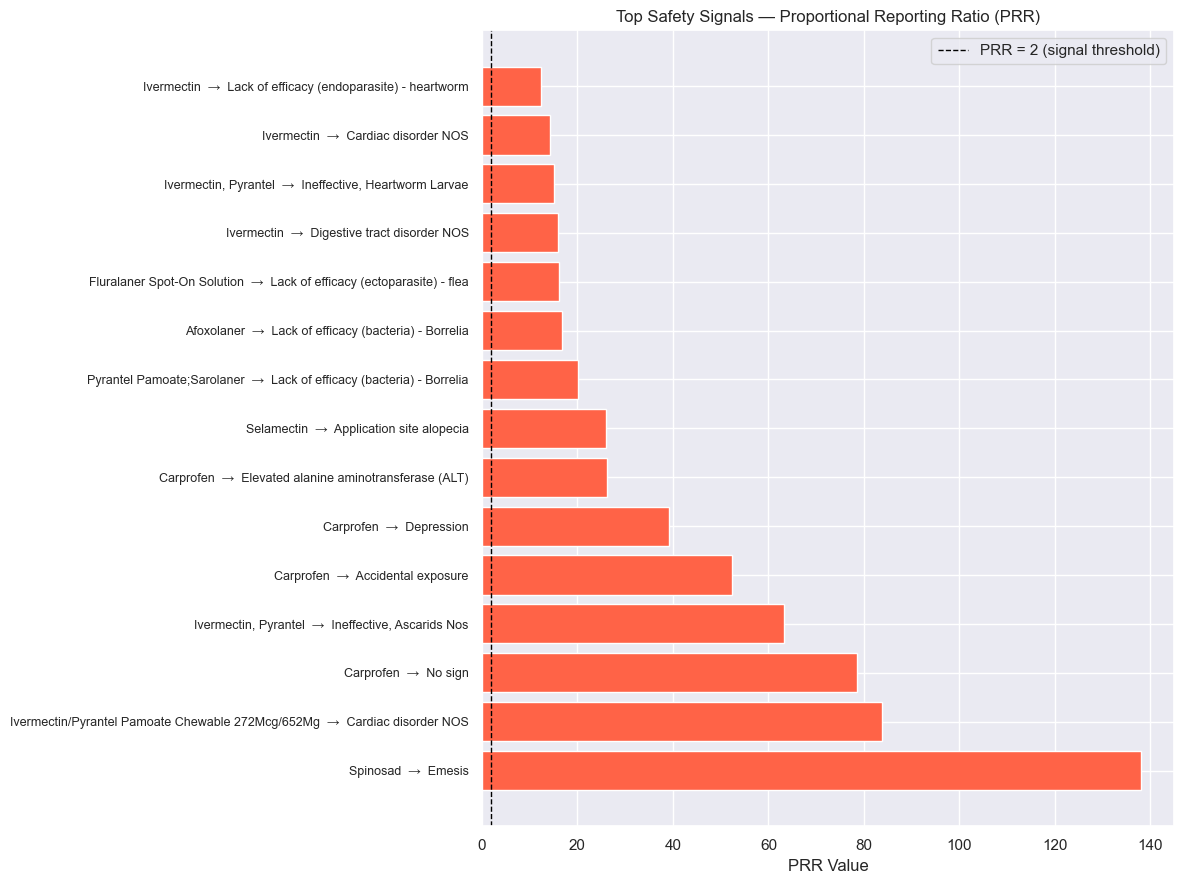


Top 10 Safety Signals:
                                             drug                                reaction  n_reports    PRR
                                         Spinosad                                  Emesis         56 138.03
Ivermectin/Pyrantel Pamoate Chewable 272Mcg/652Mg                    Cardiac disorder NOS          3  83.70
                                        Carprofen                                 No sign          3  78.48
                             Ivermectin, Pyrantel               Ineffective, Ascarids Nos          5  63.28
                                        Carprofen                     Accidental exposure          4  52.32
                                        Carprofen                              Depression          3  39.24
                                        Carprofen Elevated alanine aminotransferase (ALT)          3  26.16
                                       Selamectin               Application site alopecia          4  26.05
    

In [29]:

import numpy as np

total = len(df)
results = []

# Only analyze drugs with at least 5 reports for statistical reliability
qualified_drugs = df["drug"].value_counts()
qualified_drugs = qualified_drugs[qualified_drugs >= 5].index

for drug in qualified_drugs:
    mask_drug = df["drug"] == drug
    n_drug = int(mask_drug.sum())
    n_other = total - n_drug

    # Only reactions with at least 3 co-reports with this drug
    drug_reactions = df.loc[mask_drug, "reaction"].value_counts()
    drug_reactions = drug_reactions[drug_reactions >= 3]

    for reaction in drug_reactions.index:
        a = int((mask_drug & (df["reaction"] == reaction)).sum())
        c = int((~mask_drug & (df["reaction"] == reaction)).sum())

        if n_drug > 0 and n_other > 0 and c > 0:
            prr = (a / n_drug) / (c / n_other)
            results.append({
                "drug": drug.title(),
                "reaction": reaction,
                "n_reports": a,
                "PRR": round(prr, 2)
            })

prr_df = pd.DataFrame(results)
prr_df = prr_df[prr_df["PRR"] >= 2].sort_values("PRR", ascending=False).head(15).reset_index(drop=True)
prr_df["label"] = prr_df["drug"] + "  →  " + prr_df["reaction"]

plt.figure(figsize=(12, 9))
colors = ["tomato" if x >= 5 else "sandybrown" for x in prr_df["PRR"]]
plt.barh(range(len(prr_df)), prr_df["PRR"].values, color=colors)
plt.yticks(range(len(prr_df)), prr_df["label"].values, fontsize=9)
plt.axvline(x=2, color="black", linestyle="--", linewidth=1, label="PRR = 2 (signal threshold)")
plt.title("Top Safety Signals — Proportional Reporting Ratio (PRR)")
plt.xlabel("PRR Value")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 Safety Signals:")
print(prr_df[["drug", "reaction", "n_reports", "PRR"]].head(10).to_string(index=False))


## Seasonal Trends in Adverse Event Reporting

Antiparasitic medications are often administered in seasonal cycles (spring/summer for flea and tick prevention, year-round for heartworm). Analyzing monthly patterns can reveal whether adverse event reporting clusters around treatment seasons.


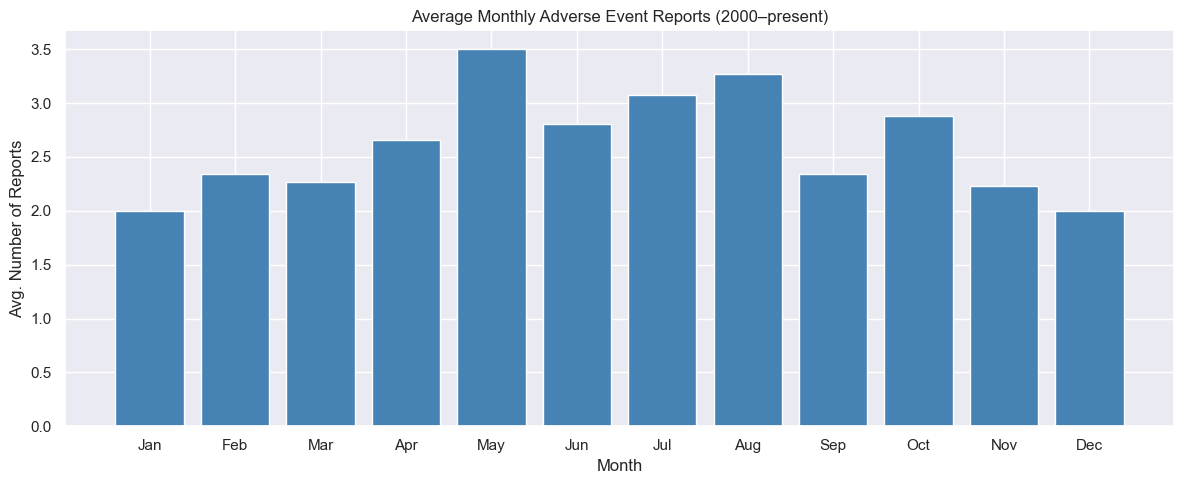

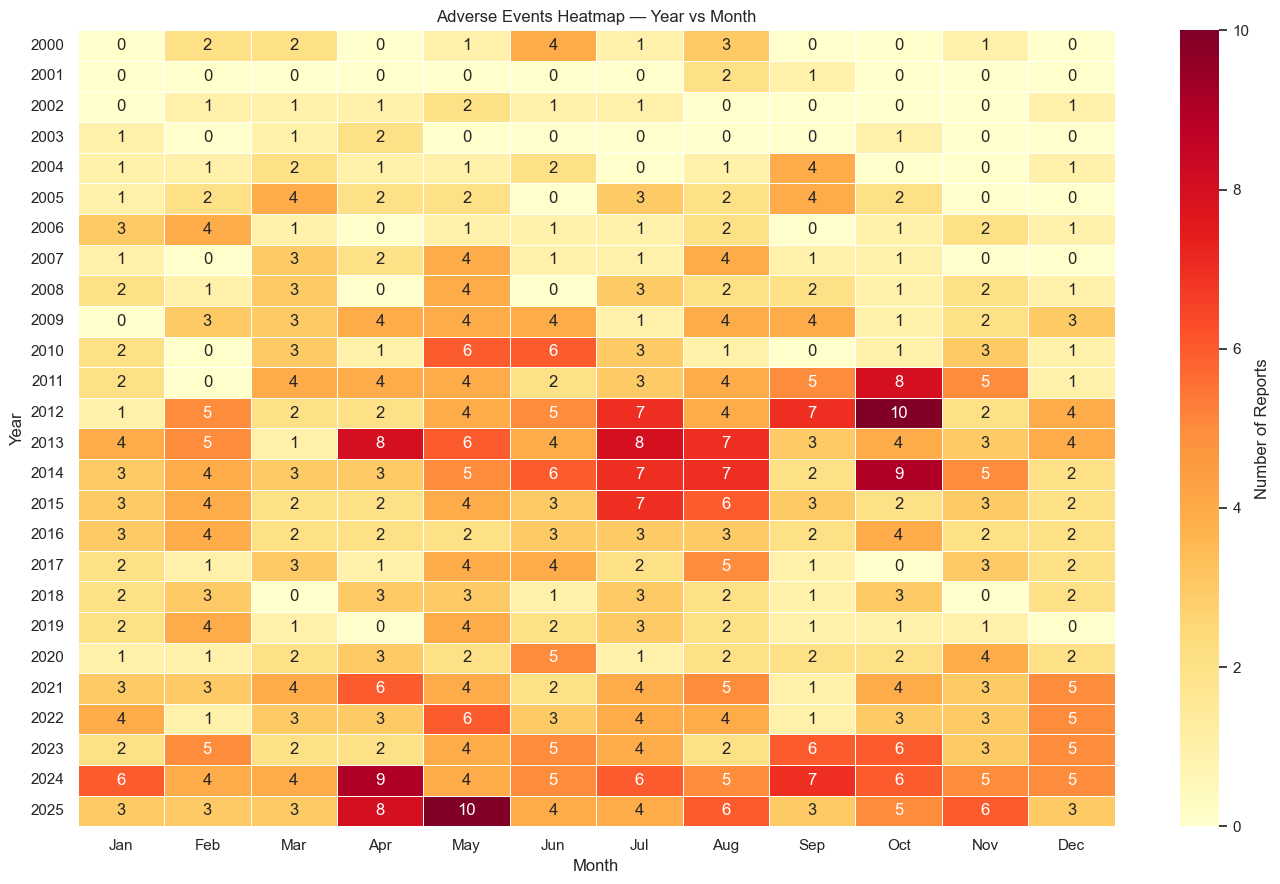

In [30]:

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_s = df.dropna(subset=["receivedate"]).copy()
df_s = df_s[df_s["receivedate"].dt.year >= 2000]
df_s["month"] = df_s["receivedate"].dt.month
df_s["year"] = df_s["receivedate"].dt.year

# Average reports per month (across all years)
n_years = df_s["year"].nunique()
monthly_avg = df_s.groupby("month").size() / n_years

plt.figure(figsize=(12, 5))
bars = plt.bar(range(1, 13), [monthly_avg.get(m, 0) for m in range(1, 13)], color="steelblue")
plt.xticks(range(1, 13), month_names)
plt.title("Average Monthly Adverse Event Reports (2000–present)")
plt.xlabel("Month")
plt.ylabel("Avg. Number of Reports")
plt.tight_layout()
plt.show()

# Heatmap: year vs month
pivot = df_s.pivot_table(index="year", columns="month", aggfunc="size", fill_value=0)
pivot.columns = [month_names[m - 1] for m in pivot.columns]

plt.figure(figsize=(14, 9))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.4, annot=True, fmt="d",
            cbar_kws={"label": "Number of Reports"})
plt.title("Adverse Events Heatmap — Year vs Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


## Key Insights

- **Species Distribution**: Dogs accounted for ~87% of adverse event reports and cats for ~13%, reflecting greater drug use and reporting frequency in canines.
- **Top Drugs**: Spinosad was the most frequently reported drug (~142 cases), followed by Ivermectin (~68) and Selamectin (~40) — predominantly antiparasitic medications.
- **Most Common Reactions**: Vomiting was the leading reaction, followed by Emesis and Lack of efficacy for heartworm/hookworm treatments. The high proportion of efficacy-related reports suggests underdosing or resistance concerns.
- **Outcome Severity**: Most outcomes were "Recovered/Normal" or "Unknown". Fatal outcomes (Died + Euthanized) represent ~5% of cases — a meaningful proportion in a pharmacovigilance context.
- **Reporting Trends**: Reports increased steadily from 2000 to a peak in 2012–2013, dipped mid-decade, then reached a new high in 2024, reflecting both increased drug use and a stronger adverse event reporting culture.
- **Breed-Specific Risk**: Labrador Retrievers were the most represented breed overall and in Ivermectin reports. German Shepherds and Australian Shepherds — known MDR1/ABCB1 mutation carriers — also appear, suggesting a genetic sensitivity link.
- **Safety Signals (PRR)**: The strongest signal was **Spinosad → Emesis** (PRR = 138), followed by Carprofen-related liver signals. These exceed the PRR ≥ 2 threshold used by regulatory agencies for formal signal investigation.
- **Seasonal Patterns**: Adverse event reporting peaks in **May** and remains elevated through summer (Jun–Aug), consistent with the spring-summer antiparasitic treatment season. January and December are the lowest-reporting months.


## Conclusion

This project delivers a comprehensive pharmacovigilance analysis of veterinary adverse drug events in dogs and cats, leveraging 1,000 records from the FDA's open adversevent database.

---

### Core Findings

The dataset is dominated by **antiparasitic medications** — Spinosad, Ivermectin, and Selamectin account for the largest share of adverse event reports. This reflects the widespread use of parasite prevention protocols in small animal practice. The most reported reactions are **gastrointestinal** (Vomiting, Emesis, Diarrhoea), **neurological** (Lethargy, Seizure NOS), and **lack of efficacy** reports for heartworm and flea treatments, which may indicate emerging resistance patterns.

---

### Outcome Severity

While most animals recovered fully, a meaningful proportion (~5%) resulted in death or euthanasia, and a large share had ongoing or unresolved outcomes. This underscores that adverse drug events in veterinary medicine carry genuine clinical risk and are not trivial in severity.

---

### Safety Signal Detection (PRR)

By applying the **Proportional Reporting Ratio** — the same methodology used by the FDA and EMA in human drug safety monitoring — this analysis detects statistically elevated drug-reaction associations beyond what simple counts reveal. The strongest signal identified was **Spinosad → Emesis** (PRR = 138), which aligns with known clinical literature on spinosad-induced vomiting. Carprofen showed multiple signals including elevated alanine aminotransferase (ALT), a well-established marker of hepatotoxicity. These findings represent actionable pharmacovigilance intelligence.

---

### Breed-Specific Risk

The breed analysis reveals that **Labrador Retrievers** are the most frequently reported breed both overall and specifically for Ivermectin adverse events. Notably, **German Shepherds** and **Australian Shepherds** — herding breeds known to carry the MDR1/ABCB1 mutation that dramatically increases Ivermectin neurotoxicity risk — also appear in the Ivermectin-specific chart. This reinforces the clinical importance of genetic screening before administering macrocyclic lactones to herding breeds.

---

### Temporal and Seasonal Trends

Reporting has trended upward over the past two decades, with a peak in 2012–2013, a mid-decade dip, and a new record high in 2024. The seasonal heatmap reveals that **May consistently generates the highest adverse event reports**, followed by summer months, which directly aligns with the spring initiation of flea, tick, and heartworm preventive treatments.

---

### Limitations & Future Work

- **Dataset size**: 1,000 records is a limited sample; full database access via pagination would allow detection of rarer signals
- **Single reaction per report**: Only the first listed reaction is currently extracted; multi-reaction modeling could reveal co-occurrence patterns
- **Breed data completeness**: Breed is not always reported, limiting the reliability of breed-level conclusions
- **Severity correlation**: A deeper statistical link between specific drugs and fatal outcomes would strengthen signal findings
- **Expand species scope**: Including horses and exotic animals would broaden pharmacovigilance coverage

This project demonstrates that FDA open data, combined with formal pharmacovigilance methods such as PRR, breed stratification, and seasonal analysis, can produce clinically meaningful insights — supporting the fundamental goal of safer drug use in veterinary medicine.
